# 팩터 2개로 만드는 factor-neutral 잔차

**Deep Learning Statistical Arbitrage (Guijarro-Ordonez, Pelger, Zanotti 2025) 학습 노트**

이 노트북은 논문의 식 (1)을 팩터 2개로 직접 계산해 보는 학습 자료예요.

$$\varepsilon_t = R_t - \beta_{t-1} F_t = \underbrace{\left(I - \beta_{t-1} w^{F\top}_{t-1}\right)}_{\Phi_{t-1}} R_t$$

**순서**

1. 행렬 대수: 팩터가 2개가 되면서 새로 필요한 것 (역행렬)
2. 장난감 예제: 4일 × 5종목, 팩터 2개(MKT, SMB)를 손으로 따라가기
3. 질문: "팩터 움직임이 잔차에 남지 않는다"는 항등식인가?
4. 한국 실제 데이터: 5종목 × 60일, 논문과 같은 rolling out-of-sample 방식
5. 정리와 직접 해보기

위에서부터 차례로 실행하세요. 파트 1–3은 numpy만 있으면 되고, 파트 4는 저장소의
`data/`(회사 데이터, git에 올리지 않음)와 replication 산출물이 필요해요.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from matplotlib import font_manager

pd.set_option("display.precision", 4)
np.set_printoptions(precision=4, suppress=True)

# 그래프의 한글 깨짐 방지: 설치된 한글 글꼴이 있으면 사용한다.
for font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if any(f.name == font for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False


def table(matrix, index, columns, digits=4):
    """행렬에 행/열 이름을 붙여 표로 보여준다."""
    return pd.DataFrame(np.asarray(matrix, dtype=float), index=index, columns=columns).round(digits)

---
## 1. 행렬 대수: 이번에 필요한 것

지난번에 본 네 가지(행렬의 크기, 곱셈, 전치, 단위행렬)를 numpy 코드로 다시 확인하고,
팩터가 2개가 되면서 새로 필요한 **역행렬**을 배워요.

### 1.1 행렬 = 숫자 표

numpy에서는 `np.array`로 만들고, 크기는 `.shape`로 확인해요. `(2, 3)`은 2행 3열이에요.

In [2]:
A = np.array([[1, 2, 3], [4, 5, 6]])
print(A)
print("크기:", A.shape)

[[1 2 3]
 [4 5 6]]
크기: (2, 3)


### 1.2 곱셈 `@` = 짝지어 곱하고 모두 더하기

numpy에서 행렬 곱은 `@` 기호로 써요. `*`는 칸끼리 곱하는 다른 연산이니 헷갈리지 마세요.

- 가로 한 줄 × 세로 한 줄 → **숫자 하나** (내적): $1\times4 + 2\times5 + 3\times6 = 32$
- 크기 규칙: $(a\times b)(b\times c) = (a\times c)$. 가운데 숫자가 같아야 곱할 수 있어요.
- 세로 한 줄 × 가로 한 줄 → **표** (각 칸 = 행 숫자 × 열 숫자)

In [3]:
row = np.array([1, 2, 3])
col = np.array([4, 5, 6])
print("내적:", row @ col)

# (2x3) @ (3,) -> (2,): A의 각 행과 col을 내적
print("A @ col:", A @ col)

# 세로 x 가로 = 표
print("세로 x 가로:\n", np.outer([2, -1], [1.5, 1.0]))

내적: 32
A @ col: [32 77]
세로 x 가로:
 [[ 3.   2. ]
 [-1.5 -1. ]]


### 1.3 전치 `.T`와 단위행렬 `np.eye`

- 전치 $A^\top$: 행과 열을 뒤집어요. 2×3이 3×2가 돼요.
- 단위행렬 $I$: 대각선만 1이고 나머지는 0이에요. 곱해도 아무것도 바뀌지 않는, 숫자 1 같은 존재예요.

In [4]:
print("A.T:\n", A.T, "\n크기:", A.T.shape)
I3 = np.eye(3)
print("A @ I = A ?", np.allclose(A @ I3, A))

A.T:
 [[1 4]
 [2 5]
 [3 6]] 
크기: (3, 2)
A @ I = A ? True


### 1.4 역행렬: "행렬로 나누기" ← 이번에 새로 필요한 것

지난번 1팩터에서 베타 공식은 $\beta = (f^\top f)^{-1} f^\top r$ 였고, $(f^\top f)^{-1}$은
그냥 "10으로 나누기"였어요. 팩터가 2개가 되면 $f^\top f$ 자리에 **2×2 표** $F^\top F$가 와요.
표로 나누는 방법이 역행렬이에요.

- 숫자: $10 \times 0.1 = 1$ 이니까 0.1은 10의 역수예요.
- 행렬: $A \times A^{-1} = I$ 가 되는 $A^{-1}$을 $A$의 역행렬이라고 해요.

2×2 역행렬은 공식 하나로 끝나요.

$$\begin{bmatrix} a & b \\ c & d \end{bmatrix}^{-1} = \frac{1}{ad-bc}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

외우는 법: **대각선(a, d)은 자리를 바꾸고, 나머지(b, c)는 부호를 바꾸고, $ad-bc$로 나눈다.**

뒤에서 실제로 쓸 행렬로 해 볼게요.

```
A = [ 10.0   -2.5 ]      ad − bc = 10×3.75 − (−2.5)×(−2.5) = 37.5 − 6.25 = 31.25
    [ -2.5    3.75]

A⁻¹ = (1/31.25) × [ 3.75   2.5 ]  =  [ 0.12   0.08 ]
                  [ 2.5   10.0 ]     [ 0.08   0.32 ]
```

$ad-bc = 0$ 이면 역행렬이 없어요(0으로 나누기). 두 팩터가 사실상 같은 움직임이라
둘을 구분할 수 없는 상황이에요. 이걸 **다중공선성**이라고 불러요.

In [5]:
A = np.array([[10.0, -2.5], [-2.5, 3.75]])
a, b, c, d = A.ravel()
A_inv_by_hand = np.array([[d, -b], [-c, a]]) / (a * d - b * c)
print("공식으로 계산:\n", A_inv_by_hand)
print("numpy로 계산:\n", np.linalg.inv(A))
print("A @ A⁻¹ = I ?\n", A @ A_inv_by_hand)

공식으로 계산:
 [[0.12 0.08]
 [0.08 0.32]]
numpy로 계산:
 [[0.12 0.08]
 [0.08 0.32]]
A @ A⁻¹ = I ?
 [[1. 0.]
 [0. 1.]]


---
## 2. 장난감 예제: 4일 × 5종목, 팩터 2개

종목1·2는 대형주, 종목3은 중형주, 종목4·5는 소형주라고 할게요. 팩터는 두 개예요.

- **MKT**: 시장 팩터. 5종목을 20%씩 담은 포트폴리오
- **SMB**: 규모 팩터(Small Minus Big). 소형주(4, 5)를 50%씩 사고 대형주(1, 2)를 50%씩 판 포트폴리오

논문의 FF3 모형에서 HML 하나를 뺀 구조예요. 수익률 단위는 %예요.

In [6]:
DAYS = ["1일", "2일", "3일", "4일"]
STOCKS = ["종목1(대)", "종목2(대)", "종목3(중)", "종목4(소)", "종목5(소)"]
FACTORS = ["MKT", "SMB"]

R = np.array(
    [
        [3.2, 2.5, 1.6, 2.35, 0.35],
        [-1.1, -1.0, 0.2, -1.55, -1.55],
        [0.9, -0.1, 1.4, 1.7, 1.1],
        [-2.3, -1.8, -2.8, -2.15, -0.95],
    ]
)
table(R, DAYS, STOCKS)

,종목1(대),종목2(대),종목3(중),종목4(소),종목5(소)
1일,3.2,2.5,1.6,2.35,0.35
2일,-1.1,-1.0,0.2,-1.55,-1.55
3일,0.9,-0.1,1.4,1.70,1.10
4일,-2.3,-1.8,-2.8,-2.15,-0.95


### 2.1 Step 1: 팩터 수익률 F = R W

두 팩터의 종목 비중을 한 표 $W$ (5×2)에 모아요. 열 하나가 팩터 하나예요.

1일 계산을 손으로 해 보면 이래요.

```
MKT = 0.2 × (3.2 + 2.5 + 1.6 + 2.35 + 0.35) = 0.2 × 10.0 = 2.0
SMB = 0.5 × (2.35 + 0.35) − 0.5 × (3.2 + 2.5) = 1.35 − 2.85 = −1.5
```

행렬로 쓰면 $F = RW$ 이고, 크기는 (4×5)(5×2) = (4×2)예요.
1팩터 때 $f = Rw$ 에서 $w$가 세로 한 줄이었다면, 이제 두 줄짜리 표가 됐을 뿐이에요.

In [7]:
W = np.array(
    [
        [0.2, -0.5],
        [0.2, -0.5],
        [0.2, 0.0],
        [0.2, 0.5],
        [0.2, 0.5],
    ]
)
display(table(W, STOCKS, FACTORS))

F = R @ W
table(F, DAYS, FACTORS)

,MKT,SMB
종목1(대),0.2,-0.5
종목2(대),0.2,-0.5
종목3(중),0.2,0.0
종목4(소),0.2,0.5
종목5(소),0.2,0.5


,MKT,SMB
1일,2.0,-1.5
2일,-1.0,-0.5
3일,1.0,1.0
4일,-2.0,0.5


표를 보면 **시장이 오른 날 SMB는 떨어지는 경향**이 있어요(1일: +2.0, −1.5 / 4일: −2.0, +0.5).
두 팩터가 서로 겹친다, 즉 상관이 있다는 뜻이에요. 실제 한국 데이터에서도 MKT와 SMB는
음의 상관을 보여요(파트 4에서 확인). 이 겹침이 다음 단계의 핵심이에요.

In [8]:
print("MKT와 SMB의 상관계수:", np.corrcoef(F[:, 0], F[:, 1])[0, 1].round(3))

MKT와 SMB의 상관계수: -0.412


### 2.2 Step 2: 베타 추정

이제 모형은 이래요. 종목마다 베타가 2개(시장 베타, SMB 베타)예요.

$$r_{i,t} = \beta_i^{M} f^{M}_t + \beta_i^{S} f^{S}_t + \varepsilon_{i,t}$$

#### (a) 먼저 틀린 방법: 팩터마다 따로 회귀하기

지난번 1팩터 공식을 MKT와 SMB에 각각 따로 쓰면 어떻게 될까요? 종목1로 해 볼게요.

```
β^M(따로) = Σ f^M·r₁ / Σ (f^M)² = 13.0 / 10.0  =  1.3
β^S(따로) = Σ f^S·r₁ / Σ (f^S)² = −4.5 / 3.75 = −1.2
```

In [9]:
beta_separate = np.column_stack([(F[:, k] @ R) / (F[:, k] @ F[:, k]) for k in range(2)])
table(beta_separate, STOCKS, ["β_MKT(따로)", "β_SMB(따로)"])

,β_MKT(따로),β_SMB(따로)
종목1(대),1.300,-1.2000
종목2(대),0.950,-1.1333
종목3(중),1.000,-0.6667
종목4(소),1.225,-0.5667
종목5(소),0.525,0.2333


**왜 틀렸을까요?** 1일에 종목1이 3.2% 오른 건 대부분 시장(+2.0%) 덕분이에요. 그런데 그날
SMB는 −1.5%였어요. SMB만 놓고 회귀하면 이 날이 "SMB가 떨어진 날 종목1이 올랐다"로 읽혀서,
**시장 덕분인 몫까지 SMB 베타(−1.2)에 끌려 들어가요.** 거꾸로 MKT 베타에도 SMB 몫이 섞여요.
두 팩터가 겹치는 부분을 양쪽에서 **이중으로 세는** 거예요.

#### (b) 올바른 방법: 다중회귀(한 번에 같이 회귀)

공식은 1팩터 때와 모양이 똑같아요. $f$가 $F$로 바뀌었을 뿐이에요.

$$B^\top = (F^\top F)^{-1} F^\top R$$

세 조각으로 나눠서 손으로 계산해 볼게요.

**① $F^\top F$ (2×2): 팩터들끼리의 내적 표**

```
                MKT                  SMB
MKT  [ Σ f^M·f^M = 10.0    Σ f^M·f^S = −2.5  ]
SMB  [ Σ f^S·f^M = −2.5    Σ f^S·f^S =  3.75 ]
```

대각선은 각 팩터의 "크기"(제곱합)이고, **대각선 밖 −2.5가 두 팩터의 겹침**이에요.
1팩터 때는 대각선 하나(10)뿐이라 겹침을 신경 쓸 필요가 없었어요.

**② $F^\top R$ (2×5): 팩터와 각 종목의 내적.** 종목1로 계산하면 이래요.

```
f^M·r₁ = 2×3.2 + (−1)×(−1.1) + 1×0.9 + (−2)×(−2.3)        = 6.4 + 1.1 + 0.9 + 4.6     = 13.0
f^S·r₁ = (−1.5)×3.2 + (−0.5)×(−1.1) + 1×0.9 + 0.5×(−2.3)  = −4.8 + 0.55 + 0.9 − 1.15 = −4.5
```

**③ 역행렬을 곱하기.** 1.4에서 구한 $(F^\top F)^{-1}$을 ②에 곱해요.

```
[ β^M ]   [ 0.12  0.08 ]   [ 13.0 ]   [ 0.12×13.0 + 0.08×(−4.5) ]   [ 1.56 − 0.36 ]   [  1.2 ]
[ β^S ] = [ 0.08  0.32 ] × [ −4.5 ] = [ 0.08×13.0 + 0.32×(−4.5) ] = [ 1.04 − 1.44 ] = [ −0.4 ]
```

따로 회귀한 값(1.3, −1.2)과 꽤 달라요. 특히 SMB 베타가 −1.2에서 −0.4로 줄었어요.
시장 몫이 빠졌기 때문이에요.

In [10]:
FtF = F.T @ F
FtF_inv = np.linalg.inv(FtF)
FtR = F.T @ R
B = (FtF_inv @ FtR).T  # 크기 (5종목 x 2팩터)

display(table(FtF, FACTORS, FACTORS))
display(table(FtF_inv, FACTORS, FACTORS))
display(table(FtR, FACTORS, STOCKS))

comparison = pd.concat(
    [
        table(beta_separate, STOCKS, ["β_MKT(따로)", "β_SMB(따로)"]),
        table(B, STOCKS, ["β_MKT(같이)", "β_SMB(같이)"]),
    ],
    axis=1,
)
comparison

,MKT,SMB
MKT,10.0,-2.50
SMB,-2.5,3.75


,MKT,SMB
MKT,0.12,0.08
SMB,0.08,0.32


,종목1(대),종목2(대),종목3(중),종목4(소),종목5(소)
MKT,13.0,9.50,10.0,12.250,5.250
SMB,-4.5,-4.25,-2.5,-2.125,0.875


,β_MKT(따로),β_SMB(따로),β_MKT(같이),β_SMB(같이)
종목1(대),1.300,-1.2000,1.2,-0.4
종목2(대),0.950,-1.1333,0.8,-0.6
종목3(중),1.000,-0.6667,1.0,-0.0
종목4(소),1.225,-0.5667,1.3,0.3
종목5(소),0.525,0.2333,0.7,0.7


#### (c) 역행렬이 하는 일: 겹치는 부분을 한 번만 세기

다중회귀의 SMB 베타는 다음 두 단계와 정확히 같아요(Frisch–Waugh–Lovell 정리).

1. SMB에서 **시장과 겹치는 부분을 먼저 빼서** "순수 SMB"를 만든다.
2. 종목 수익률을 순수 SMB에 **1팩터 회귀**한다.

$(F^\top F)^{-1}$의 대각선 밖 숫자(0.08)가 바로 이 "겹침 빼기"를 한 번에 해 주는 장치예요.
만약 두 팩터가 전혀 겹치지 않으면 $F^\top F$의 대각선 밖이 0이 되고, 따로 회귀한 결과와
같이 회귀한 결과가 같아져요.

In [11]:
f_M, f_S = F[:, 0], F[:, 1]
overlap = (f_M @ f_S) / (f_M @ f_M)  # SMB를 MKT에 회귀한 기울기 = -0.25
smb_pure = f_S - overlap * f_M  # 시장과 겹치는 부분을 뺀 순수 SMB
print("순수 SMB:", smb_pure, " / MKT와 내적:", round(f_M @ smb_pure, 10))
print("순수 SMB에 1팩터 회귀한 SMB 베타:", ((smb_pure @ R) / (smb_pure @ smb_pure)).round(4))
print("다중회귀 SMB 베타:              ", B[:, 1].round(4))

순수 SMB: [-1.   -0.75  1.25  0.  ]  / MKT와 내적: -0.0
순수 SMB에 1팩터 회귀한 SMB 베타: [-0.4 -0.6 -0.   0.3  0.7]
다중회귀 SMB 베타:               [-0.4 -0.6 -0.   0.3  0.7]


### 2.3 Step 3: 잔차 ε = R − F Bᵀ

$FB^\top$은 (4×2)(2×5) = 4×5 표예요. 각 칸은 **그날 두 팩터 수익률 × 그 종목의 두 베타를 더한 값**,
즉 팩터가 설명하는 부분이에요. 1일 종목1을 손으로 계산하면 이래요.

```
팩터 몫 = f^M × β^M + f^S × β^S = 2.0×1.2 + (−1.5)×(−0.4) = 2.4 + 0.6 = 3.0
잔차   = 3.2 − 3.0 = 0.2
```

In [12]:
factor_part = F @ B.T
E = R - factor_part
display(table(factor_part, DAYS, STOCKS))
table(E, DAYS, STOCKS)

,종목1(대),종목2(대),종목3(중),종목4(소),종목5(소)
1일,3.0,2.5,2.0,2.15,0.35
2일,-1.0,-0.5,-1.0,-1.45,-1.05
3일,0.8,0.2,1.0,1.60,1.40
4일,-2.6,-1.9,-2.0,-2.45,-1.05


,종목1(대),종목2(대),종목3(중),종목4(소),종목5(소)
1일,0.2,0.0,-0.4,0.2,-0.0
2일,-0.1,-0.5,1.2,-0.1,-0.5
3일,0.1,-0.3,0.4,0.1,-0.3
4일,0.3,0.1,-0.8,0.3,0.1


### 2.4 확인: 잔차와 두 팩터의 내적은 0

종목1 잔차 $(0.2, -0.1, 0.1, 0.3)$로 손 계산해 볼게요.

```
f^M·ε₁ = 2×0.2 + (−1)×(−0.1) + 1×0.1 + (−2)×0.3        = 0.4 + 0.1 + 0.1 − 0.6     = 0
f^S·ε₁ = (−1.5)×0.2 + (−0.5)×(−0.1) + 1×0.1 + 0.5×0.3  = −0.3 + 0.05 + 0.1 + 0.15 = 0
```

행렬로는 $F^\top \varepsilon = 0$ (2×5 영행렬)이에요.

In [13]:
table(F.T @ E, FACTORS, STOCKS, digits=10)

,종목1(대),종목2(대),종목3(중),종목4(소),종목5(소)
MKT,0.0,0.0,-0.0,0.0,-0.0
SMB,0.0,0.0,0.0,0.0,0.0


잔차 표에서 눈여겨볼 점이 두 가지 더 있어요.

- **잔차의 평균이 0이 아니에요** (종목1 평균 0.125). 회귀에 절편(상수항)을 넣지 않았기 때문이에요.
  논문 공개 코드와 이 저장소의 replication도 절편 없이 회귀해요(`fit_intercept: False`).
- **매일 5개 잔차의 합이 0이에요.** 이건 이 예제에서만 성립하는 성질이에요. 이유는 파트 3에서 볼게요.

In [14]:
print("종목별 잔차 평균:", E.mean(axis=0))
print("날짜별 잔차 합:  ", E.sum(axis=1).round(10))

종목별 잔차 평균: [ 0.125 -0.175  0.1    0.125 -0.175]
날짜별 잔차 합:   [-0. -0.  0. -0.]


### 2.5 잔차도 포트폴리오다: Φ = I − B Wᵀ

1팩터 때와 같은 논리예요. 하루치만 보면 이래요.

$$\varepsilon_t = r_t - B f_t = r_t - B (W^\top r_t) = (I - BW^\top)\, r_t = \Phi\, r_t$$

$BW^\top$은 (5×2)(2×5) = 5×5 표예요. $i$행은 **종목 $i$를 헤지하는 포트폴리오**이고,
그 비중은 "$\beta_i^M$ × MKT 비중 + $\beta_i^S$ × SMB 비중"이에요.

종목1은 $\beta^M = 1.2$, $\beta^S = -0.4$ 이니까 헤지 포트폴리오는 이래요.

```
종목1:  1.2×0.2 + (−0.4)×(−0.5) = 0.24 + 0.20 = 0.44
종목2:  1.2×0.2 + (−0.4)×(−0.5) = 0.24 + 0.20 = 0.44
종목3:  1.2×0.2 + (−0.4)×0      = 0.24
종목4:  1.2×0.2 + (−0.4)×0.5    = 0.24 − 0.20 = 0.04
종목5:  1.2×0.2 + (−0.4)×0.5    = 0.24 − 0.20 = 0.04
```

그래서 Φ의 1행은 "종목1을 1원 사고, 위 헤지 포트폴리오를 판다"예요.
자기 자신 칸은 1 − 0.44 = 0.56이 돼요.

In [15]:
hedge = B @ W.T
Phi = np.eye(5) - hedge
display(table(hedge, [f"헤지{i + 1}" for i in range(5)], STOCKS))
table(Phi, [f"잔차{i + 1}" for i in range(5)], STOCKS)

,종목1(대),종목2(대),종목3(중),종목4(소),종목5(소)
헤지1,0.44,0.44,0.24,0.04,0.04
헤지2,0.46,0.46,0.16,-0.14,-0.14
헤지3,0.20,0.20,0.20,0.20,0.20
헤지4,0.11,0.11,0.26,0.41,0.41
헤지5,-0.21,-0.21,0.14,0.49,0.49


,종목1(대),종목2(대),종목3(중),종목4(소),종목5(소)
잔차1,0.56,-0.44,-0.24,-0.04,-0.04
잔차2,-0.46,0.54,-0.16,0.14,0.14
잔차3,-0.20,-0.20,0.80,-0.20,-0.20
잔차4,-0.11,-0.11,-0.26,0.59,-0.41
잔차5,0.21,0.21,-0.14,-0.49,0.51


**1팩터와 달라진 점**: 1팩터 때는 모든 종목을 **똑같은 시장 포트폴리오**로 헤지했어요.
팩터가 2개가 되니 대형주 종목1은 주로 **다른 대형주(종목1·2)** 로, 소형주는 주로 다른 소형주로
헤지돼요. 논문이 말하는 "대상 종목과 가까운 mimicking portfolio 대비 상대 트레이드"가 바로
이거예요. 팩터가 많아질수록 종목마다 헤지가 더 맞춤형이 돼요.

검산: Φ 1행으로 1일 종목1 잔차를 다시 계산하면 이래요.

```
0.56×3.2 − 0.44×2.5 − 0.24×1.6 − 0.04×2.35 − 0.04×0.35
= 1.792 − 1.1 − 0.384 − 0.094 − 0.014 = 0.2   ✓
```

In [16]:
print("R Φᵀ 가 ε 와 같은가?", np.allclose(R @ Phi.T, E))

R Φᵀ 가 ε 와 같은가? True


### 2.6 왜 factor neutral인가: Φ B = 0

잔차 포트폴리오 1의 두 베타를 계산해 볼게요. (비중 × 각 종목 베타)를 모두 더하면 돼요.

```
시장 베타: 0.56×1.2 − 0.44×0.8 − 0.24×1.0 − 0.04×1.3 − 0.04×0.7
         = 0.672 − 0.352 − 0.24 − 0.052 − 0.028 = 0
SMB 베타:  0.56×(−0.4) − 0.44×(−0.6) − 0.24×0 − 0.04×0.3 − 0.04×0.7
         = −0.224 + 0.264 − 0 − 0.012 − 0.028 = 0
```

일반식은 1팩터 때와 똑같아요.

$$\Phi B = (I - BW^\top)B = B - B\,(W^\top B) = B - B \cdot I = 0$$

$W^\top B$ (2×2)는 **팩터 포트폴리오 자신의 베타**예요. MKT 포트폴리오의 베타는 (MKT 1, SMB 0),
SMB 포트폴리오의 베타는 (MKT 0, SMB 1)이니까 단위행렬이에요.

In [17]:
display(table(W.T @ B, ["MKT 포트폴리오", "SMB 포트폴리오"], ["β_MKT", "β_SMB"], digits=10))
table(Phi @ B, [f"잔차{i + 1}" for i in range(5)], ["β_MKT", "β_SMB"], digits=10)

,β_MKT,β_SMB
MKT 포트폴리오,1.0,-0.0
SMB 포트폴리오,0.0,1.0


,β_MKT,β_SMB
잔차1,-0.0,0.0
잔차2,-0.0,0.0
잔차3,0.0,0.0
잔차4,0.0,0.0
잔차5,-0.0,-0.0


**실제 매매로 옮기기.** 딥러닝 모델은 잔차에 대한 비중 $w^\varepsilon$을 정해요. 예를 들어
"대형주 종목1의 잔차를 사고, 소형주 종목5의 잔차를 판다"면 $w^\varepsilon = (1, 0, 0, 0, -1)$이에요.
종목 비중은 $w^R = \Phi^\top w^\varepsilon$ 이고, 논문은 이걸 절댓값 합(L1 norm)이 1이 되도록 나눠요.
어떻게 조합하든 두 팩터에 대한 노출은 0이에요.

In [18]:
w_eps = np.array([1, 0, 0, 0, -1.0])
w_R = Phi.T @ w_eps
w_R_normalized = w_R / np.abs(w_R).sum()
display(
    pd.DataFrame(
        {"종목 비중 w_R": w_R, "L1 정규화": w_R_normalized}, index=STOCKS
    ).round(4)
)
print("팩터 노출 (β_MKT, β_SMB):", (w_R @ B).round(10))

,종목 비중 w_R,L1 정규화
종목1(대),0.35,0.1667
종목2(대),-0.65,-0.3095
종목3(중),-0.10,-0.0476
종목4(소),0.45,0.2143
종목5(소),-0.55,-0.2619


팩터 노출 (β_MKT, β_SMB): [0. 0.]


---
## 3. 질문: "팩터 움직임이 잔차에 남지 않는다"는 항등식인가?

**짧은 답**: $F^\top\varepsilon = 0$ 자체는 **데이터와 상관없이 항상 성립하는 항등식**이에요.
단 조건이 하나 있어요. **β를 같은 표본에서 OLS로 추정했을 때**만이에요. 논문처럼 과거 60일로
β를 추정하고 오늘 잔차를 계산하면 항등식이 아니에요.

그리고 지난번에 "시장 움직임이 모두 빠져나갔다"고 한 건 조금 과장이었어요. 정확한 표현은
**"추정에 쓴 표본 안에서, 선형으로, 내적 기준으로 0"** 이에요.

### 3.1 증명 (네 줄)

$$\varepsilon = R - FB^\top, \qquad B^\top = (F^\top F)^{-1}F^\top R$$

$$F^\top\varepsilon = F^\top R - F^\top F\,(F^\top F)^{-1}F^\top R = F^\top R - I\,F^\top R = 0$$

숫자가 하나도 안 들어갔죠. $F^\top F$의 역행렬만 있으면 어떤 $R$, 어떤 $F$에서도 성립해요.

**직관**: OLS는 "남은 것(ε)이 팩터와 내적 0이 되도록" β를 고르는 방법이에요. 이 조건
($F^\top\varepsilon = 0$, 정규방정식 normal equation)을 β에 대해 풀면 나오는 답이 바로
$(F^\top F)^{-1}F^\top R$이에요. 결과가 조건을 만족하는 건 당연해요.

**그림으로**: 종목 수익률 벡터를 팩터들이 만드는 평면 위에 수직으로 비춘 그림자가
$FB^\top$이고, 그림자에서 원래 벡터 끝까지 이은 수직선이 ε예요. 수직이니까 내적이 0이에요.

### 3.2 아무 숫자로 확인

난수로 만든 수익률과 팩터로 몇 번 해 봐도 결과는 컴퓨터 반올림 오차(1e-15 수준)뿐이에요.

In [19]:
rng = np.random.default_rng(0)
for trial in range(3):
    R_rand = rng.normal(size=(60, 5))
    F_rand = rng.normal(size=(60, 2))
    B_rand = (np.linalg.inv(F_rand.T @ F_rand) @ F_rand.T @ R_rand).T
    E_rand = R_rand - F_rand @ B_rand.T
    print(f"시도 {trial + 1}: |Fᵀε| 최댓값 = {np.abs(F_rand.T @ E_rand).max():.1e}")

시도 1: |Fᵀε| 최댓값 = 8.3e-15
시도 2: |Fᵀε| 최댓값 = 1.4e-14
시도 3: |Fᵀε| 최댓값 = 3.1e-15


### 3.3 항등식이 아닌 것들

| 성질 | 언제 성립하나 | 장난감 예제 | 실제 데이터(논문 방식) |
|---|---|---|---|
| $F^\top\varepsilon = 0$ (팩터와 내적 0) | 같은 표본에서 OLS로 β 추정 시 **항상** | 성립 | in-sample 성립, **out-of-sample 불성립** |
| 잔차 평균 0, 팩터와 **상관** 0 | 회귀에 **절편을 넣었을 때만** | 불성립 | 불성립 |
| 매일 $W^\top\varepsilon_t = 0$ (잔차 합 0 등) | 팩터가 **바로 이 종목들로 만든** 포트폴리오일 때 | 성립 | 불성립 |
| $\Phi B = 0$ (factor neutral) | $W^\top B = I$일 때. 설계상 성립 | 성립 | 성립 (추정 β 기준) |

**(a) 내적 0 ≠ 상관 0.** 상관계수는 평균을 빼고 계산해요. 절편이 없으면 잔차 평균이 0이 아니라서,
내적은 0이어도 상관은 0이 아닐 수 있어요. 장난감 예제에서 확인해 볼게요. 절편(1로 채운 열)을
넣으면 둘 다 0이 돼요.

In [20]:
def corr_with_factors(eps, factors):
    return np.array([[np.corrcoef(eps[:, i], factors[:, k])[0, 1] for k in range(factors.shape[1])] for i in range(eps.shape[1])])


display(table(corr_with_factors(E, F), STOCKS, ["상관(MKT)", "상관(SMB)"]))

X_with_const = np.column_stack([np.ones(len(F)), F])  # 절편 + MKT + SMB
coef = np.linalg.lstsq(X_with_const, R, rcond=None)[0]
E_const = R - X_with_const @ coef
print("절편을 넣으면 잔차 평균:", E_const.mean(axis=0).round(10))
table(corr_with_factors(E_const, F), STOCKS, ["상관(MKT)", "상관(SMB)"], digits=10)

,상관(MKT),상관(SMB)
종목1(대),0.0,0.1100
종목2(대),0.0,-0.0955
종목3(중),-0.0,0.0169
종목4(소),0.0,0.1100
종목5(소),-0.0,-0.0955


절편을 넣으면 잔차 평균: [-0. -0. -0. -0. -0.]


,상관(MKT),상관(SMB)
종목1(대),-0.0,0.0
종목2(대),0.0,0.0
종목3(중),-0.0,0.0
종목4(소),-0.0,0.0
종목5(소),0.0,-0.0


MKT는 표본 평균이 0이라 원래도 상관이 0이었지만, SMB는 평균이 −0.125라서 절편 없이는 상관이
0이 아니에요.

**(b) 매일 잔차 합이 0이었던 이유.** 팩터가 바로 이 5종목의 포트폴리오($F_t = W^\top r_t$)이고
$W^\top B = I$ 이면 이렇게 돼요.

$$W^\top\varepsilon_t = W^\top r_t - W^\top B\, f_t = f_t - f_t = 0$$

MKT 비중이 20%씩이니 "MKT 방향 성분 = 0"은 곧 "5개 잔차의 합 = 0"이에요. 실제 데이터에서는 팩터가
시장 전체 약 2,000종목으로 만든 포트폴리오라 우리가 고른 5종목만으로는 이 성질이 없어요.

**(c) Out-of-sample.** 논문은 $t-1$일까지의 60일로 추정한 $\beta_{t-1}$을 $t$일 수익률에 적용해요.
그러면 $t$일 잔차는 추정에 쓰이지 않았으니 위 증명이 적용되지 않아요. 파트 4에서 직접 볼게요.

**(d) 선형, 그리고 표본 안에서만.** OLS는 팩터와의 **선형** 관계만 제거해요. 비선형 관계나
시간에 따라 변하는 베타는 잔차에 남을 수 있어요.

---
## 4. 한국 실제 데이터: 5종목 × 60일

이제 일반적인 경우를 볼게요. 설정은 이 저장소 replication의 Fama–French 잔차와 같아요.

- **종목**: 삼성전자, SK하이닉스, 현대차, NAVER, 컴투스(소형주)
- **팩터**: 한국 MKT(RMRF), SMB. 김치팩터 방법론으로 replication이 만든 value-weighted 일별 팩터
  (`outputs/kimchi-exact/daily_factor_returns.csv`). 시장 전체 종목으로 만든 포트폴리오예요.
- **수익률**: 초과수익률 = 일별 수익률 − 무위험수익률(CD 91일물 일할). 가격수익률이라 현금배당은 빠져 있어요.
- **추정**: 논문처럼 60거래일 창, 절편 없는 OLS
- 단위는 장난감 예제와 맞추려고 %로 바꿨어요. 베타는 단위를 바꿔도 같아요.

아래 셀의 값을 바꿔서 다른 종목이나 기간으로도 해 볼 수 있어요.

In [21]:
TICKERS = {
    "A005930": "삼성전자",
    "A000660": "SK하이닉스",
    "A005380": "현대차",
    "A035420": "NAVER",
    "A078340": "컴투스",
}
REAL_FACTORS = ["RMRF", "SMB"]
WINDOW_DAYS = 60  # 논문의 Fama-French loading window
WINDOW_END = "2024-06-28"  # in-sample 예시 창의 마지막 날
OOS_START, OOS_END = "2024-07-01", "2025-06-30"  # out-of-sample 잔차를 계산할 기간


def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "AGENTS.md").exists() and (path / "guijarro-ordonez-2025-replication").is_dir():
            return path
    raise FileNotFoundError("저장소 루트를 찾지 못했어요. 노트북을 저장소 안에서 실행하세요.")


REPO = find_repo_root(Path.cwd())
PROJECT = REPO / "guijarro-ordonez-2025-replication"
CONFIG = yaml.safe_load((PROJECT / "config" / "default.yml").read_text(encoding="utf-8"))

prices = pd.read_parquet(
    REPO / CONFIG["data"]["stock_daily"],
    columns=["date", "ticker", "return"],
    filters=[("ticker", "in", list(TICKERS))],
)
factor_file = pd.read_csv(REPO / CONFIG["data"]["factor_returns_daily"], parse_dates=["date"])
factor_file = factor_file.query("weight == 'vw' and frequency == 'daily'").set_index("date")

stock_returns = prices.pivot(index="date", columns="ticker", values="return")[list(TICKERS)]
panel = stock_returns.join(factor_file[[*REAL_FACTORS, "RF"]], how="inner").dropna()

X_all = panel[list(TICKERS)].sub(panel["RF"], axis=0).mul(100).rename(columns=TICKERS)  # 초과수익률, %
F_all = panel[REAL_FACTORS].mul(100).rename(columns={"RMRF": "MKT"})  # 팩터 수익률, %
NAMES = list(X_all.columns)
FNAMES = list(F_all.columns)
print(f"사용 가능 기간: {X_all.index.min().date()} ~ {X_all.index.max().date()}, {len(X_all)}거래일")

사용 가능 기간: 2018-07-02 ~ 2026-07-20, 1975거래일


### 4.1 in-sample 창: 60일 × 5종목

먼저 파트 2와 똑같이, 한 60일 창 안에서 추정하고 같은 창의 잔차를 계산해요.
$R$은 60×5, $F$는 60×2예요. 장난감 예제의 4일이 60일로 늘어났을 뿐이에요.

In [22]:
R_win = X_all.loc[:WINDOW_END].tail(WINDOW_DAYS)
F_win = F_all.loc[R_win.index]
print(f"창: {R_win.index.min().date()} ~ {R_win.index.max().date()} ({len(R_win)}일)")
display(pd.concat([R_win, F_win], axis=1).head(5).round(3))
print("이 창에서 MKT와 SMB의 상관계수:", F_win.corr().iloc[0, 1].round(3))

창: 2024-04-01 ~ 2024-06-28 (60일)


,삼성전자,SK하이닉스,현대차,NAVER,컴투스,MKT,SMB
date,,,,,,,
2024-04-01,-0.500,1.352,-2.375,3.668,1.077,0.031,0.728
2024-04-02,3.644,0.417,-3.311,-1.198,-2.172,0.179,-0.419
2024-04-03,-1.073,-3.825,-1.832,0.715,-1.117,-1.692,0.599
2024-04-04,1.413,4.897,4.616,0.451,-0.758,1.280,-0.707
2024-04-05,-0.952,-2.780,-0.235,-0.632,-0.139,-1.027,0.186


이 창에서 MKT와 SMB의 상관계수: -0.627


### 4.2 Step 2: 베타 (따로 vs 같이)

계산은 파트 2와 한 글자도 다르지 않아요. 기본 설정(2024년 2분기 창)에서는 MKT와 SMB의 상관이
−0.6 정도로 꽤 강해서, 따로 회귀한 베타와 같이 회귀한 베타가 크게 달라요. 예를 들어 삼성전자의
SMB 베타는 따로 회귀하면 음수(대형주다운 값)지만, 시장 몫을 떼어 내면 부호가 바뀌어요.

60일은 짧은 창이라 개별 베타에는 추정 오차가 커요. 논문이 매일 창을 한 칸씩 옮기며 다시
추정하는 이유 중 하나예요.

In [23]:
Fw, Rw = F_win.to_numpy(), R_win.to_numpy()
display(table(Fw.T @ Fw, FNAMES, FNAMES, digits=2))
display(table(np.linalg.inv(Fw.T @ Fw), FNAMES, FNAMES, digits=5))

B_win = (np.linalg.inv(Fw.T @ Fw) @ Fw.T @ Rw).T
B_win_separate = np.column_stack([(Fw[:, k] @ Rw) / (Fw[:, k] @ Fw[:, k]) for k in range(2)])
pd.concat(
    [
        table(B_win_separate, NAMES, ["β_MKT(따로)", "β_SMB(따로)"], digits=3),
        table(B_win, NAMES, ["β_MKT(같이)", "β_SMB(같이)"], digits=3),
    ],
    axis=1,
)

,MKT,SMB
MKT,62.07,-24.12
SMB,-24.12,23.88


,MKT,SMB
MKT,0.0265,0.0268
SMB,0.0268,0.0689


,β_MKT(따로),β_SMB(따로),β_MKT(같이),β_SMB(같이)
삼성전자,1.318,-1.124,1.451,0.342
SK하이닉스,1.816,-1.415,2.085,0.691
현대차,0.733,-1.916,-0.019,-1.936
NAVER,0.364,0.265,0.768,1.041
컴투스,0.065,0.250,0.266,0.519


### 4.3 Step 3: 잔차와 항등식 확인

실제 데이터에서도 $F^\top\varepsilon$은 반올림 오차 수준으로 0이에요. **항등식이니까요.**
반면 장난감 예제에서 성립했던 두 성질은 여기서는 성립하지 않아요.

- 잔차 평균 ≠ 0 (절편 없음)
- 날짜별 5개 잔차의 합 ≠ 0 (팩터가 이 5종목으로 만든 포트폴리오가 아님)

R²는 두 팩터가 각 종목 변동의 몇 %를 설명했는지예요(절편 없는 회귀라 제곱합 기준).
삼성전자처럼 시장 비중이 큰 종목은 팩터가 많이 설명하고, 소형주 컴투스는 거의 설명하지 못해요.

In [24]:
E_win = Rw - Fw @ B_win.T
print(f"in-sample Fᵀε 의 최대 절댓값: {np.abs(Fw.T @ E_win).max():.1e}  (반올림 오차 수준)")
summary = pd.DataFrame(
    {
        "잔차 평균(%)": E_win.mean(axis=0),
        "R²": 1 - (E_win**2).sum(axis=0) / (Rw**2).sum(axis=0),
    },
    index=NAMES,
).round(4)
display(summary)
print("날짜별 잔차 합(처음 5일):", E_win.sum(axis=1)[:5].round(3))

in-sample Fᵀε 의 최대 절댓값: 3.5e-14  (반올림 오차 수준)


,잔차 평균(%),R²
삼성전자,-0.0310,0.5987
SK하이닉스,0.4396,0.4945
현대차,0.3053,0.2572
NAVER,-0.1586,0.1913
컴투스,-0.1070,0.0309


날짜별 잔차 합(처음 5일): [ 2.605 -3.158  0.174  5.258 -0.183]


### 4.4 실제 데이터에서의 Φ: 팩터를 "자산"으로 거래하기

장난감 예제에서는 팩터가 5종목의 포트폴리오라 Φ가 5×5였어요. 실제 팩터는 시장 전체로 만든
포트폴리오라서, 논문(과 이 저장소의 FF 구현)은 **팩터 자체를 거래 가능한 자산으로 추가**해요.

자산이 [5종목, MKT 자산, SMB 자산] 7개가 되고, 잔차 포트폴리오 $i$는
"종목 $i$ 1원 매수 + MKT 자산 $\beta_i^M$원 매도 + SMB 자산 $\beta_i^S$원 매도"예요.
합성행렬은 $[\,I \mid -B\,]$ (5×7)이에요.

사실 이것도 같은 공식 $\Phi = I - \beta W^\top$이에요. 7개 자산의 베타는 $\tilde\beta = [B;\ I]$,
팩터 비중은 $\tilde W = [0;\ I]$ (팩터 = 팩터 자산 그 자체)로 두면
$\tilde\Phi = I - \tilde\beta\tilde W^\top$의 위 5행이 정확히 $[\,I \mid -B\,]$가 돼요.

In [25]:
composition = np.hstack([np.eye(5), -B_win])  # [I | -B], 크기 5 x 7
extended_returns = np.hstack([Rw, Fw])  # 7개 자산 수익률, 크기 60 x 7
extended_betas = np.vstack([B_win, np.eye(2)])  # 종목 베타 + 팩터 자산 자신의 베타(=I)

display(table(composition, [f"잔차({n})" for n in NAMES], [*NAMES, "MKT 자산", "SMB 자산"], digits=3))
print("[I|-B] 로 만든 포트폴리오 수익률 = ε ?", np.allclose(extended_returns @ composition.T, E_win))
print("잔차 포트폴리오의 팩터 노출:\n", (composition @ extended_betas).round(12))

,삼성전자,SK하이닉스,현대차,NAVER,컴투스,MKT 자산,SMB 자산
잔차(삼성전자),1.0,0.0,0.0,0.0,0.0,-1.451,-0.342
잔차(SK하이닉스),0.0,1.0,0.0,0.0,0.0,-2.085,-0.691
잔차(현대차),0.0,0.0,1.0,0.0,0.0,0.019,1.936
잔차(NAVER),0.0,0.0,0.0,1.0,0.0,-0.768,-1.041
잔차(컴투스),0.0,0.0,0.0,0.0,1.0,-0.266,-0.519


[I|-B] 로 만든 포트폴리오 수익률 = ε ? True
잔차 포트폴리오의 팩터 노출:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


### 4.5 논문 방식: rolling out-of-sample 잔차

논문은 look-ahead를 피하려고 매일 이렇게 해요.

1. $t$일 직전 60거래일($t-60 \sim t-1$)로 $\beta_{t-1}$을 추정한다.
2. $t$일 잔차 $\varepsilon_t = R_t - \beta_{t-1} F_t$ 를 계산한다. ($t$일 데이터는 추정에 안 쓰였다)
3. 다음 날 창을 한 칸 옮겨 반복한다.

이렇게 1년 치 잔차를 모으면 $F^\top\varepsilon$은 **더 이상 0이 아니에요.** 비교를 위해 같은 1년을
통째로 한 번에 in-sample 회귀한 잔차도 같이 계산해요.

In [26]:
dates = X_all.index
i_start = dates.searchsorted(pd.Timestamp(OOS_START))
i_end = dates.searchsorted(pd.Timestamp(OOS_END), side="right")
assert i_start >= WINDOW_DAYS, "OOS 시작 전에 60일 이상의 이력이 필요해요."

oos_eps, oos_beta = [], []
for i in range(i_start, i_end):
    F_past = F_all.iloc[i - WINDOW_DAYS : i].to_numpy()  # t-60 ~ t-1
    R_past = X_all.iloc[i - WINDOW_DAYS : i].to_numpy()
    B_prev = (np.linalg.inv(F_past.T @ F_past) @ F_past.T @ R_past).T  # β_{t-1}
    oos_eps.append(X_all.iloc[i].to_numpy() - B_prev @ F_all.iloc[i].to_numpy())
    oos_beta.append(B_prev)

oos_dates = dates[i_start:i_end]
eps_oos = pd.DataFrame(oos_eps, index=oos_dates, columns=NAMES)
beta_oos = np.array(oos_beta)  # 크기 (날짜, 종목, 팩터)
F_oos = F_all.loc[oos_dates]

# 같은 기간을 한 번에 in-sample 회귀 (비교용)
Fy, Ry = F_oos.to_numpy(), X_all.loc[oos_dates].to_numpy()
eps_ins = Ry - Fy @ (np.linalg.inv(Fy.T @ Fy) @ Fy.T @ Ry)

print(f"OOS 기간: {oos_dates.min().date()} ~ {oos_dates.max().date()} ({len(oos_dates)}일)")
check = pd.concat(
    {
        "in-sample Fᵀε": table(Fy.T @ eps_ins, FNAMES, NAMES, digits=10).T,
        "OOS Fᵀε": table(Fy.T @ eps_oos.to_numpy(), FNAMES, NAMES, digits=2).T,
        "OOS 상관": table(corr_with_factors(eps_oos.to_numpy(), Fy).T, FNAMES, NAMES, digits=3).T,
    },
    axis=1,
)
check

OOS 기간: 2024-07-01 ~ 2025-06-30 (241일)


in-sample Fᵀε      OOS Fᵀε        OOS 상관       
                 MKT  SMB     MKT    SMB    MKT    SMB
삼성전자             0.0 -0.0  -52.20  -9.33 -0.106 -0.045
SK하이닉스           0.0 -0.0 -132.67 -44.07 -0.152 -0.094
현대차              0.0 -0.0   29.97  -2.18  0.054 -0.017
NAVER            0.0 -0.0   67.13  -0.37  0.082  0.004
컴투스              0.0 -0.0   75.26 -10.37  0.087 -0.024

in-sample은 여전히 정확히 0이고, OOS는 0이 아니에요. 다만 OOS 상관은 대부분 ±0.2 안쪽으로 작아요.
논문의 factor neutral은 **추정된 $\beta_{t-1}$ 기준(ex-ante)의 중립**이에요. 실제로 실현된
노출(ex-post)은 베타 추정 오차와 베타의 시간 변화만큼 남아요.

베타가 실제로 얼마나 움직이는지 그려 볼게요. 매일 창을 옮겨 다시 추정해야 하는 이유가 보여요.

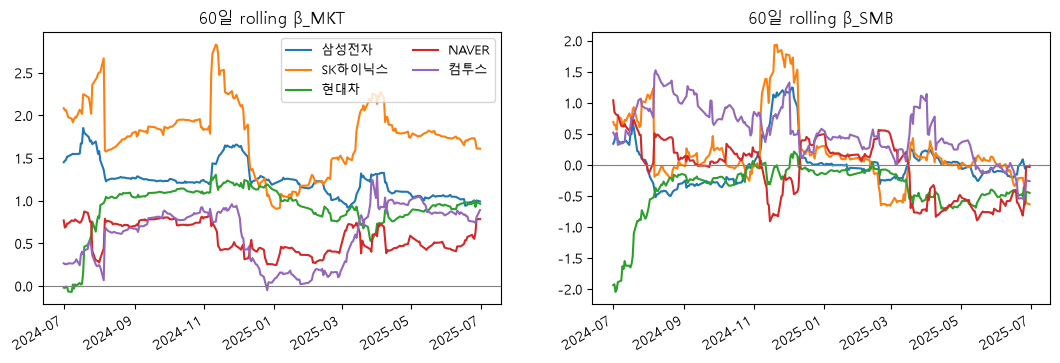

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for k, ax in enumerate(axes):
    for j, name in enumerate(NAMES):
        ax.plot(oos_dates, beta_oos[:, j, k], label=name)
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_title(f"60일 rolling β_{FNAMES[k]}")
axes[0].legend(ncol=2, fontsize=9)
fig.autofmt_xdate()
plt.show()

마지막으로 한 종목의 누적 수익률을 보면 factor neutral이 눈에 보여요. 원래 초과수익률은
시장과 함께 크게 오르내리지만, 잔차는 시장의 큰 움직임을 따라가지 않아요.
DLSA는 이 **누적 잔차**(직전 30일)의 모양을 보고 매매 비중을 정해요.

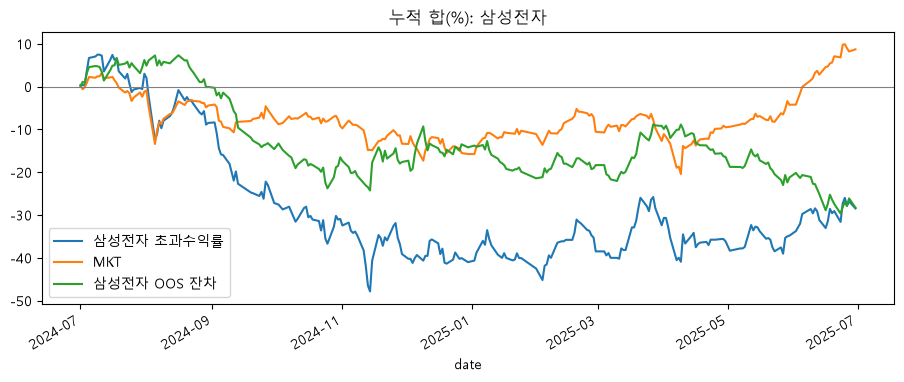

In [28]:
target = NAMES[0]
cumulative = pd.DataFrame(
    {
        f"{target} 초과수익률": X_all.loc[oos_dates, target],
        "MKT": F_oos["MKT"],
        f"{target} OOS 잔차": eps_oos[target],
    }
).cumsum()
ax = cumulative.plot(figsize=(11, 4), title=f"누적 합(%): {target}")
ax.axhline(0, color="gray", lw=0.8)
plt.show()

### 4.6 검산: 이 노트북의 계산 = 저장소 replication의 계산

같은 방식으로 **팩터 1개(MKT만, 논문의 FF1)** 잔차를 계산해서, replication이 만든
`outputs/fama-french/daily_residuals_ff1_*.parquet`과 비교해요. replication 표본(시가총액 필터 등)에
들어간 종목만 비교할 수 있어요. 차이가 1e-15 수준이면 이 노트북이 저장소와 같은 계산을 하고 있다는 뜻이에요.

In [29]:
ff1_path = PROJECT / "outputs" / "fama-french" / "daily_residuals_ff1_20200102_l60.parquet"
if ff1_path.exists():
    replication = pd.read_parquet(ff1_path).query("date >= @oos_dates.min() and date <= @oos_dates.max()")
    replication = replication.pivot(index="date", columns="ticker", values="residual") * 100
    common = [t for t in TICKERS if t in replication.columns]
    f_mkt = F_all[["MKT"]]
    diffs = {}
    for ticker in common:
        name = TICKERS[ticker]
        mine = []
        for i in range(i_start, i_end):
            f_past = f_mkt.iloc[i - WINDOW_DAYS : i].to_numpy()
            r_past = X_all[name].iloc[i - WINDOW_DAYS : i].to_numpy()
            beta_prev = np.linalg.lstsq(f_past, r_past, rcond=None)[0]
            mine.append(X_all[name].iloc[i] - f_mkt.iloc[i].to_numpy() @ beta_prev)
        mine = pd.Series(mine, index=oos_dates)
        theirs = replication[ticker].reindex(oos_dates)
        diffs[name] = {"비교 일수": int(theirs.notna().sum()), "최대 절대차(%p)": (mine - theirs).abs().max()}
    display(pd.DataFrame.from_dict(diffs, orient="index"))
    print("replication 표본에 없는 종목:", [TICKERS[t] for t in TICKERS if t not in common])
else:
    print("replication FF1 잔차 파일이 없어 검산을 건너뛰어요:", ff1_path)

,비교 일수,최대 절대차(%p)
삼성전자,241,1.1324e-14
SK하이닉스,241,1.2434e-14
현대차,241,1.2879e-14


replication 표본에 없는 종목: ['NAVER', '컴투스']


---
## 5. 정리

**팩터 2개의 3단계**

| 단계 | 1팩터 | 2팩터 |
|---|---|---|
| 팩터 수익률 | $f = Rw$ (4×1) | $F = RW$ (4×2) |
| 베타 | $\beta^\top = (f^\top f)^{-1}f^\top R$, "10으로 나누기" | $B^\top = (F^\top F)^{-1}F^\top R$, **역행렬이 겹침을 교정** |
| 잔차 | $\varepsilon = R - f\beta^\top$ | $\varepsilon = R - FB^\top$ |
| 포트폴리오 | $\Phi = I - \beta w^\top$, 모두 같은 시장 헤지 | $\Phi = I - BW^\top$, **종목마다 맞춤형 헤지** |
| 중립성 | $\Phi\beta = 0$ | $\Phi B = 0$ (두 팩터 모두) |

**질문에 대한 답**

- $F^\top\varepsilon = 0$은 OLS의 항등식이에요. 같은 표본에서 추정하면 어떤 데이터든 성립해요.
- 하지만 논문은 out-of-sample로 잔차를 만들기 때문에 실제 잔차에서는 0이 아니에요(작을 뿐).
- 절편이 없으면 "내적 0"이지 "상관 0"은 아니에요.
- 매일 잔차 합이 0이던 건 팩터를 그 5종목으로 만든 장난감 예제의 특수한 성질이었어요.
- 논문의 factor neutral은 추정 베타 기준의 중립($\Phi B = 0$)이고, 이건 설계상 항상 성립해요.

### 직접 해보기

1. **파트 2**: `W`의 SMB 비중을 바꿔 보세요(예: 종목3도 매도). 베타와 Φ는 바뀌지만 `Phi @ B`는 여전히 0이에요.
   왜 그런지 $W^\top B$를 출력해서 생각해 보세요. (힌트: 팩터를 팩터 자신에 회귀하면?)
2. **파트 4**: `WINDOW_DAYS`를 20이나 120으로 바꿔 보세요. rolling 베타의 흔들림과 OOS 상관이 어떻게 변하나요?
3. **파트 4**: `TICKERS`에 다른 종목을 넣거나 기간을 바꿔 보세요.

### 다음 주제: PCA

이번에는 팩터 포트폴리오 $W$가 미리 주어졌어요(MKT, SMB). **PCA는 이 $W$ 자체를 데이터에서 찾아요.**
"종목들이 가장 같이 움직이는 방향"을 과거 252일 상관행렬의 고유벡터로 뽑아서 $W$로 쓰고, 그다음은
이 노트북과 똑같이 60일 회귀로 β를 구해요. 그래서 다음에는 분산, 공분산 행렬, 고유벡터를 배울 거예요.